# Baseline 2: ResNet50 + Prototypical Network (Few-Shot Learning)

This notebook implements **Baseline 2**, where a **ResNet50 backbone** is used with a **Prototypical Network head**.

We evaluate the model under **few-shot settings**:
- 1-shot
- 5-shot
- 10-shot

Only the **final-layer features (layer4 output)** of ResNet50 are used.

## 1. Imports

In [9]:
import os, random
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Image Transform (ResNet50 expects 224×224)

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3. Few-Shot Dataset Loader (Episodic Sampling)

Each episode contains:
- N-way classification (N = 4)
- K support images per class
- Q query images per class

In [11]:
class FewShotDataset:
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_images = {
            cls: os.listdir(os.path.join(root_dir, cls))
            for cls in self.classes
        }

    def sample_episode(self, n_way, k_shot, q_query):
        support_images, support_labels = [], []
        query_images, query_labels = [], []

        selected_classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(selected_classes):
            # Handle insufficient images by reusing available ones
            images = self.class_to_images[cls]
            if len(images) < k_shot + q_query:
                print(f"⚠️ Not enough images in class '{cls}'. Reusing available images.")
                images = (images * ((k_shot + q_query) // len(images) + 1))[:k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)
            cls_path = os.path.join(self.root_dir, cls)

            # Support set
            for img_name in sampled_images[:k_shot]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                support_images.append(self.transform(img))
                support_labels.append(label)

            # Query set
            for img_name in sampled_images[k_shot:]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                query_images.append(self.transform(img))
                query_labels.append(label)

        return (
            torch.stack(support_images),
            torch.tensor(support_labels),
            torch.stack(query_images),
            torch.tensor(query_labels)
        )

## 4. ResNet50 Encoder

We remove the final fully connected (fc) layer and use only the **layer4 output** followed by global average pooling.

**Output embedding dimension:** 2048

In [12]:
class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)

        # Remove classification head (fc)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.encoder(x)          # Shape: (B, 2048, 1, 1)
        x = x.view(x.size(0), -1)    # Shape: (B, 2048)
        return x

## 5. Prototypical Network Head

Class prototypes are computed as the **mean embedding of support samples**.
Classification is performed using **Euclidean distance**.

In [13]:
class ProtoNet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, support_x, support_y, query_x):
        # Encode support and query images
        support_emb = self.encoder(support_x)
        query_emb = self.encoder(query_x)

        # Compute class prototypes
        prototypes = []
        for c in torch.unique(support_y):
            class_emb = support_emb[support_y == c]
            prototypes.append(class_emb.mean(dim=0))
        prototypes = torch.stack(prototypes)

        # Compute distances (query → prototypes)
        distances = torch.cdist(query_emb, prototypes)

        # Negative distances act as logits
        return -distances

## 6. Training and Evaluation Function

A **separate model is trained for each K-shot setting**.

In [14]:
def train_and_evaluate(k_shot, episodes_train=100, episodes_eval=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data = FewShotDataset("clean_dataset/val", transform)

    model = ProtoNet(ResNet50Encoder()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # ---------------- Training ----------------
    model.train()
    for episode in range(episodes_train):
        print(f"Training episode {episode + 1}/{episodes_train}...")
        sx, sy, qx, qy = train_data.sample_episode(
            n_way=4, k_shot=k_shot, q_query=10
        )

        sx, sy = sx.to(device), sy.to(device)
        qx, qy = qx.to(device), qy.to(device)

        scores = model(sx, sy, qx)
        loss = F.cross_entropy(scores, qy)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ---------------- Evaluation ----------------
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for eval_episode in range(episodes_eval):
            print(f"Evaluating episode {eval_episode + 1}/{episodes_eval}...")
            sx, sy, qx, qy = val_data.sample_episode(
                n_way=4, k_shot=k_shot, q_query=10
            )

            sx, sy = sx.to(device), sy.to(device)
            qx, qy = qx.to(device), qy.to(device)

            preds = model(sx, sy, qx).argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(qy.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm

## 7. Run 1-Shot Experiments

RUNNING 1-SHOT EXPERIMENTS
Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training e

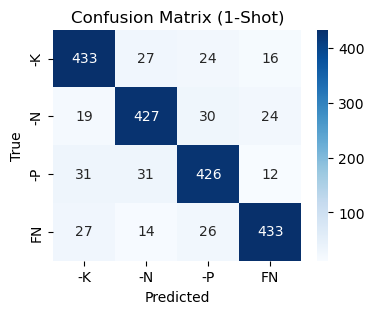

In [15]:
print("=" * 50)
print("RUNNING 1-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(1)
print(f"\nResNet50 + ProtoNet | 1-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix (1-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 8. Run 5-Shot Experiments

RUNNING 10-SHOT EXPERIMENTS


C:\Users\HI\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HI\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

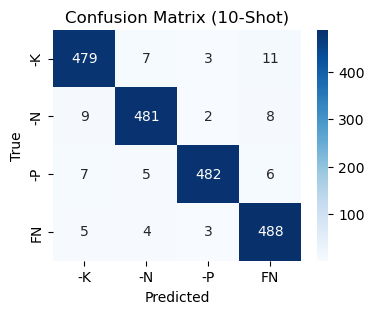

In [16]:
print("=" * 50)
print("RUNNING 10-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(10)
print(f"\nResNet50 + ProtoNet | 10-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix (10-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 9. Run 10-Shot Experiments

RUNNING 5-SHOT EXPERIMENTS
Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training e

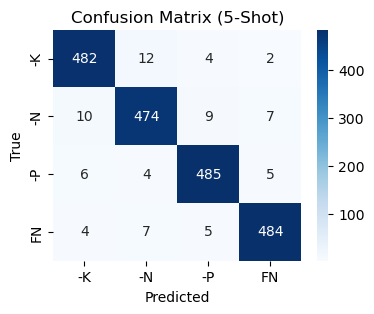

In [18]:
print("=" * 50)
print("RUNNING 5-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(5)
print(f"\nResNet50 + ProtoNet | 5-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix (5-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [1]:
import pandas as pd

data = {
    'Shots': [1, 5, 10],
    'Accuracy': [0.8595, 0.9625, 0.9650]
}

df = pd.DataFrame(data)

# Derive Percentage from Accuracy
df["Percentage"] = df["Accuracy"]

styled_df = (
    df.style
      .set_caption("Baseline 2: ResNet50 + ProtoNet")
      .format({
          "Accuracy": "{:.4f}",
          "Percentage": "{:.2%}"
      })
      .set_properties(**{"text-align": "center"})
)

styled_df


,Shots,Accuracy,Percentage
0,1,0.8595,85.95%
1,5,0.9625,96.25%
2,10,0.9650,96.50%
